In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Load financial indicators (your first uploaded Excel file)
df_financial = pd.read_csv('/content/drive/MyDrive/Datasets/Merged.csv')

# Load daily closing price dataset
df_price = pd.read_csv('/content/drive/MyDrive/Datasets/Price.csv')

# Show samples
df_financial.head(), df_price.head()

(                    Company  Year Quarter  Earnings Per Share (EPS) Rs  \
 0  Hatton National Bank PLC  2025      Q1                        17.89   
 1  Hatton National Bank PLC  2024      Q4                        33.46   
 2  Hatton National Bank PLC  2024      Q3                        11.96   
 3  Hatton National Bank PLC  2024      Q2                        15.97   
 4  Hatton National Bank PLC  2024      Q1                        10.91   
 
    Dividend per Share Rs  Dividend Payout Ratio  Return on Equity (ROE) %  \
 0                   15.0                   0.84                     17.61   
 1                   15.0                   0.45                     20.40   
 2                    NaN                    NaN                     15.15   
 3                    NaN                    NaN                     16.02   
 4                    8.0                   0.73                     13.29   
 
    Return on Asset (ROA) %  Debt-to-Equity Ratio (%) Net Profit Rs '000  
 0 

In [ ]:
df_financial.info()
df_financial.describe()
df_financial.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 468 entries, 0 to 467
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Company                      468 non-null    object 
 1   Year                         468 non-null    int64  
 2   Quarter                      468 non-null    object 
 3   Earnings Per Share (EPS) Rs  468 non-null    float64
 4   Dividend per Share Rs        308 non-null    float64
 5   Dividend Payout Ratio        150 non-null    float64
 6   Return on Equity (ROE) %     343 non-null    float64
 7   Return on Asset (ROA) %      331 non-null    float64
 8   Debt-to-Equity Ratio (%)     392 non-null    float64
 9   Net Profit Rs '000           468 non-null    object 
dtypes: float64(6), int64(1), object(3)
memory usage: 36.7+ KB


,0
Company,0
Year,0
Quarter,0
Earnings Per Share (EPS) Rs,0
Dividend per Share Rs,160
Dividend Payout Ratio,318
Return on Equity (ROE) %,125
Return on Asset (ROA) %,137
Debt-to-Equity Ratio (%),76
Net Profit Rs '000,0


In [ ]:
# Convert 'Year' to integer
df_financial['Year'] = df_financial['Year'].astype(int)

# Convert 'Quarter' from "Q1", "Q2", etc. to integers
df_financial['Quarter'] = df_financial['Quarter'].map({'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4})

# Convert 'Net Profit Rs '000' to float (remove commas first)
df_financial["Net Profit Rs '000"] = (
    df_financial["Net Profit Rs '000"]
    .replace({',': ''}, regex=True)
    .astype(float)
)
df_financial.head()

,Company,Year,Quarter,Earnings Per Share (EPS) Rs,Dividend per Share Rs,Dividend Payout Ratio,Return on Equity (ROE) %,Return on Asset (ROA) %,Debt-to-Equity Ratio (%),Net Profit Rs '000
0,Hatton National Bank PLC,2025,1,17.89,15.0,0.84,17.61,2.96,81.85,10229296.0
1,Hatton National Bank PLC,2024,4,33.46,15.0,0.45,20.40,4.03,16.85,20539224.0
2,Hatton National Bank PLC,2024,3,11.96,NaN,NaN,15.15,2.51,19.43,6838350.0
3,Hatton National Bank PLC,2024,2,15.97,NaN,NaN,16.02,2.65,16.40,9130939.0
4,Hatton National Bank PLC,2024,1,10.91,8.0,0.73,13.29,2.02,18.45,6237310.0


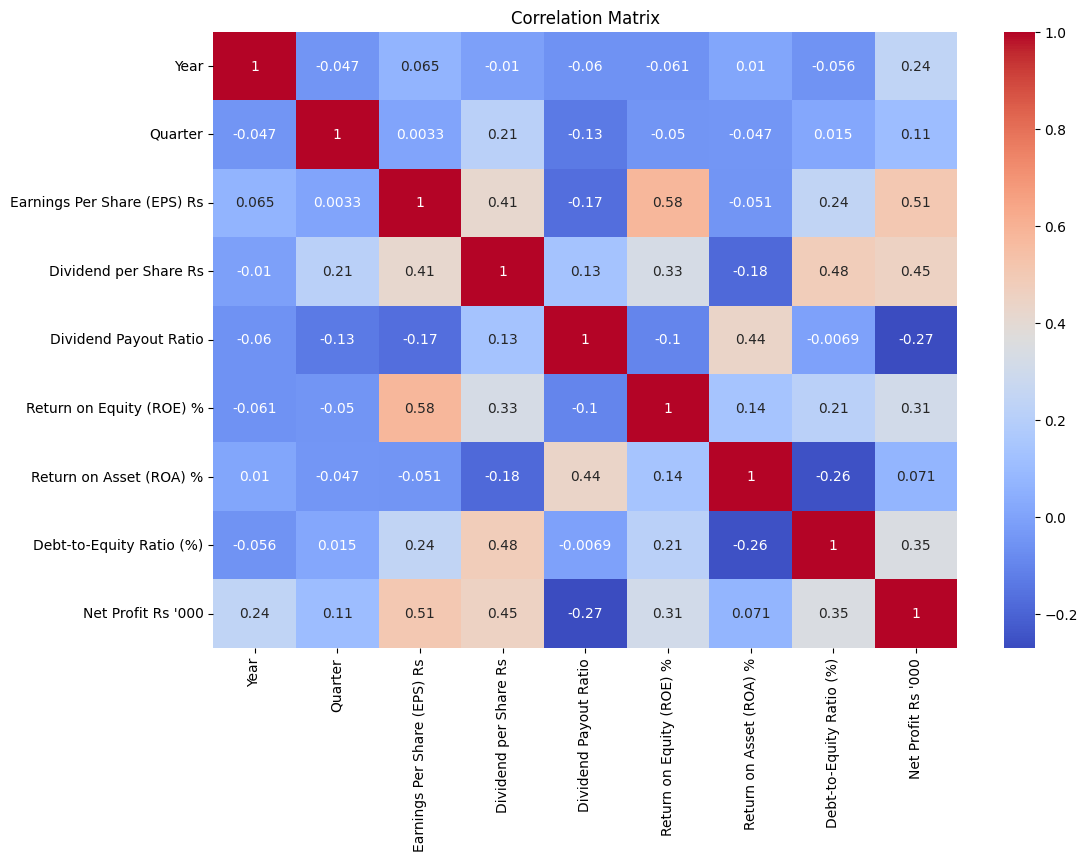

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df_financial.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Create a numerical 'Period' to represent quarters (e.g., 2024.0, 2024.25, etc.)
df_financial['Period'] = df_financial['Year'] + (df_financial['Quarter'] - 1) * 0.25
df_financial.head()

,Company,Year,Quarter,Earnings Per Share (EPS) Rs,Dividend per Share Rs,Dividend Payout Ratio,Return on Equity (ROE) %,Return on Asset (ROA) %,Debt-to-Equity Ratio (%),Net Profit Rs '000,Period
0,Hatton National Bank PLC,2025,1,17.89,15.0,0.84,17.61,2.96,81.85,10229296.0,2025.00
1,Hatton National Bank PLC,2024,4,33.46,15.0,0.45,20.40,4.03,16.85,20539224.0,2024.75
2,Hatton National Bank PLC,2024,3,11.96,NaN,NaN,15.15,2.51,19.43,6838350.0,2024.50
3,Hatton National Bank PLC,2024,2,15.97,NaN,NaN,16.02,2.65,16.40,9130939.0,2024.25
4,Hatton National Bank PLC,2024,1,10.91,8.0,0.73,13.29,2.02,18.45,6237310.0,2024.00


In [ ]:
# Group by Company for filling missing values with company-specific medians
company_group = df_financial.groupby('Company')

# Function to apply median imputation per company
def fill_with_group_median(df, column):
    return df[column].fillna(company_group[column].transform('median'))

# Columns to fill using median values
median_cols = [
    'Earnings Per Share (EPS) Rs', # Corrected column name
    'Return on Equity (ROE) %',
    'Return on Asset (ROA) %',
    'Debt-to-Equity Ratio (%)',
    'Net Profit Rs \'000' # Corrected column name from previous fix
]

# Fill missing values in each financial column
for col in median_cols:
    df_financial[col] = fill_with_group_median(df_financial, col)

# List of dividend-related columns
dividend_cols = ['Dividend per Share Rs', 'Dividend Payout Ratio']

# Create binary indicators for missingness
for col in dividend_cols:
    df_financial[f'{col}_missing'] = df_financial[col].isnull().astype(int)
    df_financial[col] = df_financial[col].fillna(0)  # Financial logic: no dividend declared

df_financial.head()

,Company,Year,Quarter,Earnings Per Share (EPS) Rs,Dividend per Share Rs,Dividend Payout Ratio,Return on Equity (ROE) %,Return on Asset (ROA) %,Debt-to-Equity Ratio (%),Net Profit Rs '000,Period,Dividend per Share Rs_missing,Dividend Payout Ratio_missing
0,Hatton National Bank PLC,2025,1,17.89,15.0,0.84,17.61,2.96,81.85,10229296.0,2025.00,0,0
1,Hatton National Bank PLC,2024,4,33.46,15.0,0.45,20.40,4.03,16.85,20539224.0,2024.75,0,0
2,Hatton National Bank PLC,2024,3,11.96,0.0,0.00,15.15,2.51,19.43,6838350.0,2024.50,1,1
3,Hatton National Bank PLC,2024,2,15.97,0.0,0.00,16.02,2.65,16.40,9130939.0,2024.25,1,1
4,Hatton National Bank PLC,2024,1,10.91,8.0,0.73,13.29,2.02,18.45,6237310.0,2024.00,0,0


In [ ]:
# Sort the dataset so each company's data is in time order
df_financial.sort_values(['Company', 'Year', 'Quarter'], inplace=True)
df_financial.reset_index(drop=True, inplace=True)

df_financial.head()

,Company,Year,Quarter,Earnings Per Share (EPS) Rs,Dividend per Share Rs,Dividend Payout Ratio,Return on Equity (ROE) %,Return on Asset (ROA) %,Debt-to-Equity Ratio (%),Net Profit Rs '000,Period,Dividend per Share Rs_missing,Dividend Payout Ratio_missing
0,Chevron Lubricants Lanka PLC,2015,1,6.19,6.0,97.0,50.0,NaN,0.50,743663.0,2015.00,0,0
1,Chevron Lubricants Lanka PLC,2015,2,6.64,5.0,75.3,50.0,NaN,0.31,797150.0,2015.25,0,0
2,Chevron Lubricants Lanka PLC,2015,3,6.96,11.0,158.0,50.0,NaN,0.24,834764.0,2015.50,0,0
3,Chevron Lubricants Lanka PLC,2016,1,8.22,6.0,73.0,50.0,NaN,0.39,985921.0,2016.00,0,0
4,Chevron Lubricants Lanka PLC,2016,2,3.34,8.0,239.5,50.0,NaN,0.44,801960.0,2016.25,0,0


In [ ]:
# Convert 'Trade Date' to datetime
df_price['Trade Date'] = pd.to_datetime(df_price['Trade Date'])

# Create a 'Quarter' column in "YYYY-Qn" format
df_price['Quarter'] = df_price['Trade Date'].dt.to_period('Q').astype(str)

# Group by Company Name and Quarter and get mean Close and Open price
df_quarterly_price = df_price.groupby(['Company Name', 'Quarter']).agg({
    'Close (Rs.)': 'mean',
    'Open (Rs.)': 'mean'
}).reset_index()

df_quarterly_price.rename(columns={'Close (Rs.)': 'Avg_Close_Price', 'Open (Rs.)': 'Avg_Open_Price'}, inplace=True)

# Split 'Quarter' (e.g., '2023Q1') into Year and Quarter number
df_quarterly_price['Year'] = df_quarterly_price['Quarter'].str[:4].astype(int)
df_quarterly_price['Q_Num'] = df_quarterly_price['Quarter'].str[-1].astype(int)

# Now compute 'Period' correctly
df_quarterly_price['Period'] = df_quarterly_price['Year'] + (df_quarterly_price['Q_Num'] - 1) * 0.25

# Optional: drop Q_Num if not needed
df_quarterly_price.drop(columns='Q_Num', inplace=True)

df_quarterly_price.head()

/tmp/ipython-input-1143173144.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_price['Trade Date'] = pd.to_datetime(df_price['Trade Date'])


,Company Name,Quarter,Avg_Close_Price,Avg_Open_Price,Year,Period
0,CENTRAL FINANCE COMPANY PLC,2015Q1,258.616364,258.589091,2015,2015.00
1,CENTRAL FINANCE COMPANY PLC,2015Q2,260.301724,260.081034,2015,2015.25
2,CENTRAL FINANCE COMPANY PLC,2015Q3,261.855000,262.315000,2015,2015.50
3,CENTRAL FINANCE COMPANY PLC,2015Q4,247.322034,247.176271,2015,2015.75
4,CENTRAL FINANCE COMPANY PLC,2016Q1,226.480357,227.166071,2016,2016.00


In [ ]:
features = [
    'Earnings Per Share (EPS) Rs',
    'Dividend per Share Rs',
    'Dividend Payout Ratio',
    'Return on Equity (ROE) %',
    'Return on Asset (ROA) %',
    'Debt-to-Equity Ratio (%)',
    'Net Profit Rs \'000',
]
target = 'Target_Close_Price'

In [ ]:
# Step 1: Rename company column for consistency if needed
df_financial.rename(columns={'Company': 'Company Name'}, inplace=True)

# Step 2: Sort price data to ensure correct shifting
df_quarterly_price.sort_values(['Company Name', 'Period'], inplace=True)

# Step 3: Shift the close price backwards by 1 quarter per company
df_quarterly_price['Target_Close_Price'] = df_quarterly_price.groupby('Company Name')['Avg_Close_Price'].shift(-1)

# Step 4: Keep only relevant columns for merging
df_target = df_quarterly_price[['Company Name', 'Period', 'Target_Close_Price']]

# Standardize company names in both datasets
df_financial['Company Name'] = df_financial['Company Name'].str.title()
df_target['Company Name'] = df_target['Company Name'].str.title()

df_final = pd.merge(df_financial, df_target, how='inner', on=['Company Name', 'Period'])

# Step 6: Drop rows where target is missing (i.e., last quarter for each company)
df_final.dropna(subset=features + [target], inplace=True)

df_final.head()

/tmp/ipython-input-2064683702.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_target['Company Name'] = df_target['Company Name'].str.title()


,Company Name,Year,Quarter,Earnings Per Share (EPS) Rs,Dividend per Share Rs,Dividend Payout Ratio,Return on Equity (ROE) %,Return on Asset (ROA) %,Debt-to-Equity Ratio (%),Net Profit Rs '000,Period,Dividend per Share Rs_missing,Dividend Payout Ratio_missing,Target_Close_Price
33,Commercial Bank Of Ceylon Plc,2015,1,2.87,0.0,0.00,14.93,1.81,25.59,2508682.0,2015.00,1,1,134.349123
34,Commercial Bank Of Ceylon Plc,2015,2,3.02,0.0,0.00,14.81,1.87,23.99,2659295.0,2015.25,1,1,134.229508
35,Commercial Bank Of Ceylon Plc,2015,3,3.71,0.0,0.00,15.97,1.95,23.41,3249524.0,2015.50,1,1,127.970492
36,Commercial Bank Of Ceylon Plc,2015,4,3.97,4.5,1.13,16.90,2.05,22.91,3477370.0,2015.75,0,0,114.181034
37,Commercial Bank Of Ceylon Plc,2016,1,3.69,0.0,0.00,19.24,2.04,31.62,3234315.0,2016.00,1,1,112.215000


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 409 entries, 33 to 466
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Company Name                   409 non-null    object 
 1   Year                           409 non-null    int64  
 2   Quarter                        409 non-null    int64  
 3   Earnings Per Share (EPS) Rs    409 non-null    float64
 4   Dividend per Share Rs          409 non-null    float64
 5   Dividend Payout Ratio          409 non-null    float64
 6   Return on Equity (ROE) %       409 non-null    float64
 7   Return on Asset (ROA) %        409 non-null    float64
 8   Debt-to-Equity Ratio (%)       409 non-null    float64
 9   Net Profit Rs '000             409 non-null    float64
 10  Period                         409 non-null    float64
 11  Dividend per Share Rs_missing  409 non-null    int64  
 12  Dividend Payout Ratio_missing  409 non-null    int64  

In [ ]:
df_sampath = df_final[df_final['Company Name'] == 'Sampath Bank Plc'].copy()
df_sampath = df_sampath.sort_values(by='Period').reset_index(drop=True)
df_sampath.head()

,Company Name,Year,Quarter,Earnings Per Share (EPS) Rs,Dividend per Share Rs,Dividend Payout Ratio,Return on Equity (ROE) %,Return on Asset (ROA) %,Debt-to-Equity Ratio (%),Net Profit Rs '000,Period,Dividend per Share Rs_missing,Dividend Payout Ratio_missing,Target_Close_Price
0,Sampath Bank Plc,2015,1,8.52,0.0,0.00,19.20,2.9,18.66,1431058.0,2015.00,1,1,258.284483
1,Sampath Bank Plc,2015,2,9.08,0.0,0.00,18.61,1.9,18.12,3206295.0,2015.25,1,1,262.801587
2,Sampath Bank Plc,2015,3,10.17,0.0,0.00,18.42,1.9,6.00,1751641.0,2015.50,1,1,254.383607
3,Sampath Bank Plc,2015,4,8.05,13.0,1.61,18.42,1.9,6.00,1535978.0,2015.75,0,0,231.085965
4,Sampath Bank Plc,2016,1,10.09,0.0,0.00,19.78,1.9,18.12,1739025.0,2016.00,1,1,230.928333


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_x.fit_transform(df_sampath[features])
y_scaled = scaler_y.fit_transform(df_sampath[[target]])

# Convert to sequences
def create_sequences(X, y, time_steps=3):
    Xs, ys = [], []
    for i in range(time_steps, len(X)):
        Xs.append(X[i-time_steps:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps=3)

# Train-test split
split_index = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split_index], X_seq[split_index:]
y_train, y_test = y_seq[:split_index], y_seq[split_index:]

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, activation='relu', input_shape=(X_seq.shape[1], X_seq.shape[2])),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=100, batch_size=8, verbose=1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.3356
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2849
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1996
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2121
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1830
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1066
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0754
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0723
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0673
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0724
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0741
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0723
Epoch 13/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0421
Epoch 14/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0576
Epoch 15/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0462
Epoch 16/100
4/4 ━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


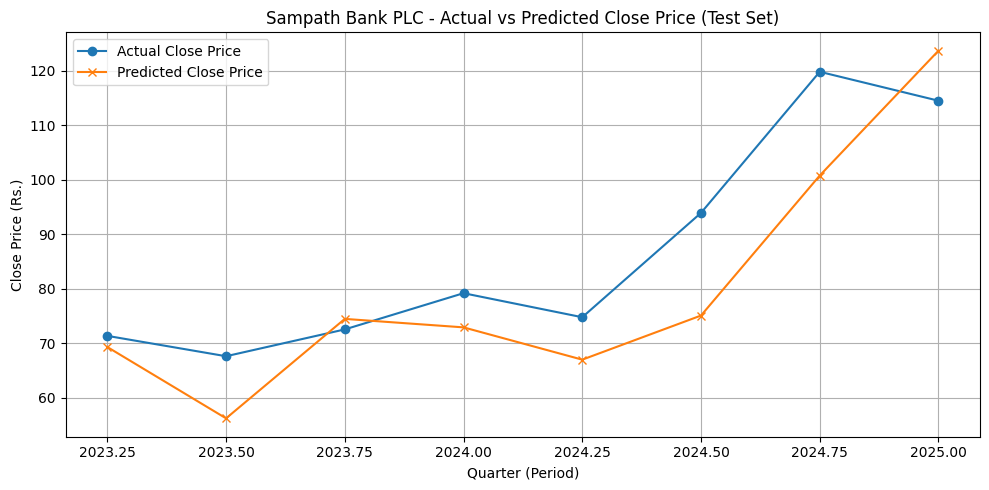

In [ ]:
import matplotlib.pyplot as plt

# Predict on test data
y_pred_test_scaled = model.predict(X_test)
y_pred_test = scaler_y.inverse_transform(y_pred_test_scaled)
y_true_test = scaler_y.inverse_transform(y_test)

# Create test period timeline (starts after time_steps + train size)
plot_test_periods = df_sampath['Period'].values[3 + len(y_train):]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(plot_test_periods, y_true_test, label='Actual Close Price', marker='o')
plt.plot(plot_test_periods, y_pred_test, label='Predicted Close Price', marker='x')
plt.xlabel('Quarter (Period)')
plt.ylabel('Close Price (Rs.)')
plt.title('Sampath Bank PLC - Actual vs Predicted Close Price (Test Set)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_true_test, y_pred_test)
mse = mean_squared_error(y_true_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_test, y_pred_test)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 9.57
Mean Squared Error (MSE): 130.10
Root Mean Squared Error (RMSE): 11.41
R² Score: 0.6441


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

def permutation_importance_lstm(model, X_test, y_test, scaler_y, feature_names, baseline_rmse=None):
    if baseline_rmse is None:
        y_pred_baseline = scaler_y.inverse_transform(model.predict(X_test))
        y_true = scaler_y.inverse_transform(y_test)
        baseline_rmse = np.sqrt(mean_squared_error(y_true, y_pred_baseline))

    print(f'Baseline RMSE: {baseline_rmse:.2f}')

    importances = []
    for i in range(X_test.shape[2]):
        X_test_permuted = X_test.copy()
        np.random.shuffle(X_test_permuted[:, :, i])

        y_pred_permuted = scaler_y.inverse_transform(model.predict(X_test_permuted))
        rmse_permuted = np.sqrt(mean_squared_error(y_true, y_pred_permuted))

        importance = rmse_permuted - baseline_rmse
        importances.append((feature_names[i], importance))

    importances.sort(key=lambda x: x[1], reverse=True)
    return importances


In [ ]:
feature_names = features  # Your original financial features
importances = permutation_importance_lstm(model, X_test, y_test, scaler_y, feature_names)

# Display
for feat, imp in importances:
    print(f"{feat:40s} Importance: {imp:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Baseline RMSE: 11.41
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Dividend Payout Ratio                    Importance: 15.8772
Net Profit Rs '000                       Importance: 12.2399
Debt-to-Equity Ratio (%)                 Importance: 9.8294
Dividend per Share Rs                    Importance: 4.3310
Earnings Per Share (EPS) Rs              Importance: 3.0985
Return on Equity (ROE) %                 Importance: 0.7650
Return on Asset (ROA) %                  Importance: 0.1814


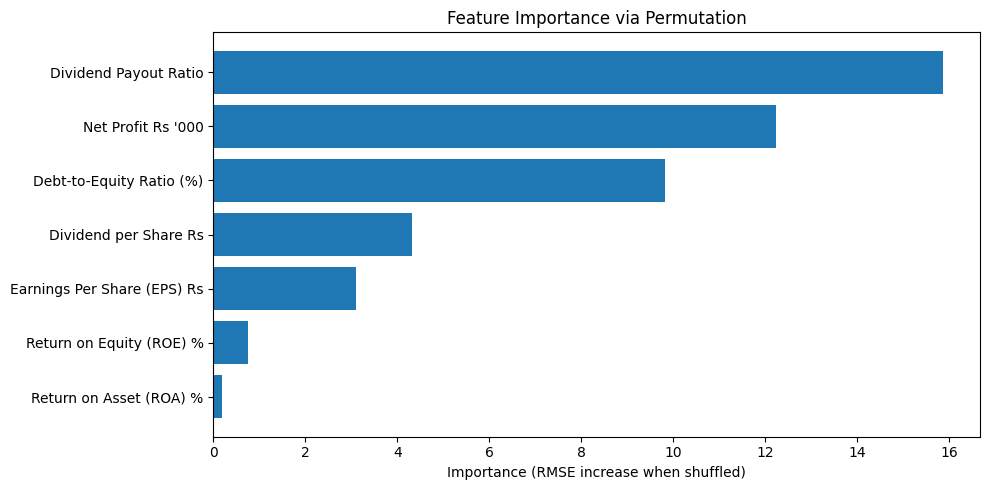

In [ ]:
import matplotlib.pyplot as plt

# Unpack
feat_names, scores = zip(*importances)

plt.figure(figsize=(10, 5))
plt.barh(feat_names, scores)
plt.xlabel('Importance (RMSE increase when shuffled)')
plt.title('Feature Importance via Permutation')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()